### Гипотеза 6: Аугментации + больше эпох + Label Smoothing

**Идея:** Комбинация трёх техник для борьбы с переобучением на специфике train-набора:
1. **Аугментации** — не дают модели зазубрить train, заставляют учить общие признаки
2. **30 эпох + CosineAnnealingLR** — достаточно времени для сходимости с плавным снижением LR
3. **Label Smoothing (0.1)** — не даёт confidence доходить до 1.0, предотвращает «уверенное переобучение»

Импорт библиотек и загрузка результатов

In [1]:
from common import *
all_results = load_results()

Загрузка параметров и подготовка данных

In [ ]:
with open("outputs/splits_info.json", "r") as f: # загрузка параметров
    cfg = json.load(f)

CLASS_NAMES = cfg["class_names"] # названия классов
BATCH_SIZE = cfg["batch_size"] # размер батча
IMG_SIZE = cfg["img_size"] # размер изображения
SEED = cfg["seed"] # seed
train_indices = cfg["train_indices"] # индексы train
val_indices = cfg["val_indices"] # индексы val

# аугментированный трансформ для train
train_transform_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # изменение размера изображения
    transforms.RandomHorizontalFlip(), # случайное горизонтальное отражение
    transforms.RandomRotation(15), # случайное вращение
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # случайные изменения яркости, контраста, насыщенности и оттенка
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)), # случайные аффинные преобразования
    transforms.ToTensor(), # преобразование в тензор
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]) # нормализация
])

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform_aug) # создание train-набора
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание val-набора
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание test-набора

train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # выборка train-набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # выборка val-набора

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True) # создание train-loader
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание val-loader
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True) # создание test-loader

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 7965, Val: 1992, Test: 2487


Функция обучения с Label Smoothing + CosineAnnealing

In [ ]:
def train_model_aug_smooth(model, model_name, train_loader, val_loader, test_loader,
                           epochs=30, lr=1e-3, label_smoothing=0.1, device=DEVICE):
    """ Функция обучения с Label Smoothing + CosineAnnealing """
    set_seed(SEED)
    model = model.to(device) # перенос модели на GPU
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing) # критерий
    optimizer = optim.Adam(model.parameters(), lr=lr) # оптимизатор
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) # scheduler

    scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None # масштабирование градиентов

    history = {"train_loss": [], "val_loss": [], "val_acc": [], "train_acc": []} # история обучения

    for epoch in range(epochs): # проход по эпохам
        model.train() # перевод модели в режим обучения
        running_loss = 0.0 # счетчик потерь
        all_preds = [] # список предсказаний
        all_labels = [] # список меток
 
        for images, labels in train_loader: # проход по батчам
            images, labels = images.to(device), labels.to(device) # перенос на GPU
            optimizer.zero_grad() # обнуление градиентов

            if scaler: # если масштабирование градиентов
                with torch.amp.autocast('cuda'): # автомасштабирование градиентов
                    outputs = model(images) # предсказания модели
                    loss = criterion(outputs, labels) # вычисление потерь
                scaler.scale(loss).backward() # масштабирование градиентов
                scaler.step(optimizer) # обновление весов
                scaler.update() # обновление масштаба
            else: # если нет масштабирования градиентов
                outputs = model(images) # предсказания модели
                loss = criterion(outputs, labels) # вычисление потерь
                loss.backward() # обратная связь
                optimizer.step() # обновление весов

            running_loss += loss.item() * images.size(0) # суммирование потерь
            _, preds = torch.max(outputs, 1) # предсказания модели
            all_preds.extend(preds.cpu().numpy()) # добавление предсказаний в список
            all_labels.extend(labels.cpu().numpy()) # добавление меток в список

        train_loss = running_loss / len(train_loader.dataset) # средние потери
        train_acc = accuracy_score(all_labels, all_preds) # точность

        val_loss, val_acc, val_bal_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device) # оценка на валидационном наборе
        scheduler.step() # обновление scheduler

        history["train_loss"].append(train_loss) # добавление потерь в историю
        history["val_loss"].append(val_loss) # добавление потерь в историю
        history["train_acc"].append(train_acc) # добавление точности в историю
        history["val_acc"].append(val_acc) # добавление точности в историю

        print(f"Epoch {epoch+1}/{epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, "
              f"Val Bal Acc: {val_bal_acc:.4f}, Val F1: {val_f1:.4f}")

    test_criterion = nn.CrossEntropyLoss() # критерии на тесте
    test_loss, test_acc, test_bal_acc, test_f1, test_preds, test_labels = evaluate(
        model, test_loader, test_criterion, device
    ) # оценка на тестовом наборе

    # вывод метрик на тесте
    print(f"\n{model_name} - TEST")
    print(f"Accuracy: {test_acc:.4f}")
    print(f"Balanced Accuracy: {test_bal_acc:.4f}")
    print(f"Macro-F1: {test_f1:.4f}")

    # матрица ошибок
    cm = confusion_matrix(test_labels, test_preds)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    # графики потерь и точности
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].legend()
    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Val")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    
    # отчет о классификации
    print(f"{model_name} - Classification Report:")
    print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES))

    # возвращение результатов
    return {
        "model": model_name,
        "test_acc": test_acc,
        "test_bal_acc": test_bal_acc,
        "test_f1_macro": test_f1,
        "history": history,
        "confusion_matrix": cm.tolist(),
    }

Обучение ResNet18 с аугментациями, 30 эпохами и Label Smoothing

Epoch 1/30 - Train Loss: 0.6634, Train Acc: 0.8354, Val Loss: 0.6975, Val Acc: 0.8489, Val Bal Acc: 0.8495, Val F1: 0.8370
Epoch 2/30 - Train Loss: 0.4860, Train Acc: 0.9391, Val Loss: 0.5281, Val Acc: 0.9302, Val Bal Acc: 0.9304, Val F1: 0.9296
Epoch 3/30 - Train Loss: 0.4468, Train Acc: 0.9620, Val Loss: 0.7488, Val Acc: 0.8047, Val Bal Acc: 0.8044, Val F1: 0.8025
Epoch 4/30 - Train Loss: 0.4210, Train Acc: 0.9733, Val Loss: 0.4458, Val Acc: 0.9533, Val Bal Acc: 0.9535, Val F1: 0.9523
Epoch 5/30 - Train Loss: 0.4054, Train Acc: 0.9812, Val Loss: 0.3824, Val Acc: 0.9930, Val Bal Acc: 0.9930, Val F1: 0.9930
Epoch 6/30 - Train Loss: 0.3995, Train Acc: 0.9827, Val Loss: 0.3995, Val Acc: 0.9769, Val Bal Acc: 0.9770, Val F1: 0.9770
Epoch 7/30 - Train Loss: 0.3901, Train Acc: 0.9852, Val Loss: 0.3760, Val Acc: 0.9925, Val Bal Acc: 0.9925, Val F1: 0.9925
Epoch 8/30 - Train Loss: 0.3830, Train Acc: 0.9893, Val Loss: 0.3640, Val Acc: 0.9995, Val Bal Acc: 0.9995, Val F1: 0.9995
Epoch 9/30 - Tra

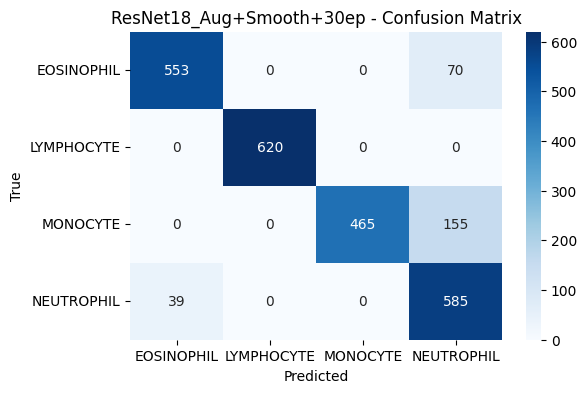

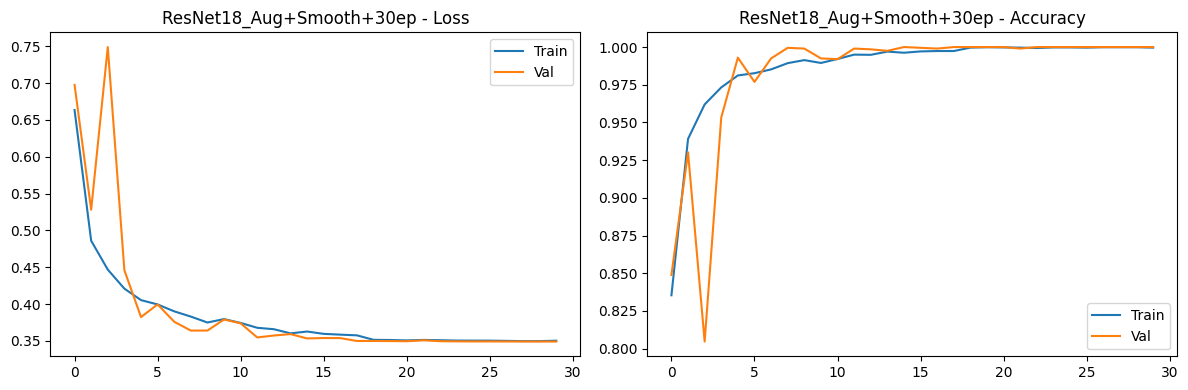

ResNet18_Aug+Smooth+30ep - Classification Report:
              precision    recall  f1-score   support

  EOSINOPHIL       0.93      0.89      0.91       623
  LYMPHOCYTE       1.00      1.00      1.00       620
    MONOCYTE       1.00      0.75      0.86       620
  NEUTROPHIL       0.72      0.94      0.82       624

    accuracy                           0.89      2487
   macro avg       0.91      0.89      0.90      2487
weighted avg       0.91      0.89      0.90      2487



In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT) # создание модели ResNet18
model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES)) # изменение последнего слоя

result = train_model_aug_smooth(
    model, "ResNet18_Aug+Smooth+30ep",
    train_loader, val_loader, test_loader,
    epochs=30,
    lr=1e-3,
    label_smoothing=0.1
)

In [ ]:
torch.save(model.state_dict(), "outputs/resnet18_aug_smooth_30ep.pth") # сохранение модели

Комбинация всех улучшений дала наилучший результат для ResNet18: Accuracy 0.8938, Balanced Accuracy 0.8938, Macro-F1 0.8958 — прирост +3.9% по сравнению с baseline (0.8544). Гипотеза подтверждена. Кривые обучения значительно сглажены относительно baseline и отдельных гипотез: label smoothing предотвратил уверенное переобучение (train loss оставался в диапазоне 0.35–0.66 — выше нуля), аугментация расширила эффективный объём обучающих данных, а CosineAnnealingLR обеспечил мягкое убывание LR на длинном горизонте 30 эпох. Синергия этих трёх факторов оказалась значительно эффективнее каждого по отдельности.

Сохранение результатов

In [ ]:
all_results = load_results()
all_results["ResNet18_Aug+Smooth+30ep"] = result # добавление результатов в словарь

df_cosine = pd.DataFrame([result]) # создание DataFrame
baseline_models = pd.DataFrame([
    all_results["baseline_resnet18"],
    all_results["baseline_swin"]
])

df_compare = pd.concat([baseline_models, df_cosine], ignore_index=True) # создание DataFrame

print("Baseline vs CosineAnnealingLR:")
display(df_compare[["model", "test_acc", "test_bal_acc", "test_f1_macro"]])
save_results(all_results)

Baseline vs CosineAnnealingLR:


,model,test_acc,test_bal_acc,test_f1_macro
0,ResNet18,0.854443,0.854462,0.858832
1,Swin-T,0.880177,0.880147,0.883016
2,ResNet18_Aug+Smooth+30ep,0.893848,0.893785,0.895833


Результаты сохранены в outputs/experiment_results.pkl


Гипотеза подтверждена. Наилучший результат среди всех экспериментов с ResNet18. Комбинирование техник регуляризации (аугментация, label smoothing) с более длинным обучением под cosine-расписанием — наиболее действенная стратегия для CNN.